# 🌦️ 03 — THỜI TIẾT (Weather) · bộ TP.HCM

Bóc tách ảnh hưởng của **thời tiết** tới **giá** và **hệ số nhân**.

> Boston kết luận thời tiết ≈0 (thiếu ngày mưa + thiếu mắt xích). HCM mưa nhiều → đo được rõ hơn.

> ### 📌 Đọc kèm `00_TONG_HOP_SO_SANH.ipynb`
>
> Notebook này đo giờ trên **giá cuối** và **hệ số nhân**. Điểm cần nhớ khi viết báo cáo:
> - η(giờ → **giá cơ bản**) ≈ 0,03 — rất nhỏ (giá cơ bản do quãng đường/thời gian quyết định)
> - η(giờ → **hệ số nhân**) ≈ 0,70 — **rất mạnh**, đây là kênh tác động thật
> - η(giờ → **giá cuối**) ≈ 0,30 — vì giá cuối = giá cơ bản × hệ số nhân
>
> → Kết luận đúng: **giờ ảnh hưởng mạnh đến giá khách trả, thông qua surge.**

In [1]:
import sys; sys.path.insert(0, ".")
from _common import *
setup()
df = load(frac=0.15)   # doi frac=1.0 de nap toan bo

Nap 1,034,550 dong (mau 15%) | gia median 114k VND | surge 81.7%


## 1. Phân bố các loại thời tiết

Phan bo loai thoi tiet: {'Rain': 468851, 'Clouds': 316381, 'Clear': 230933, 'Mist': 18385}
weather_missing (thieu quan sat): 1.71%


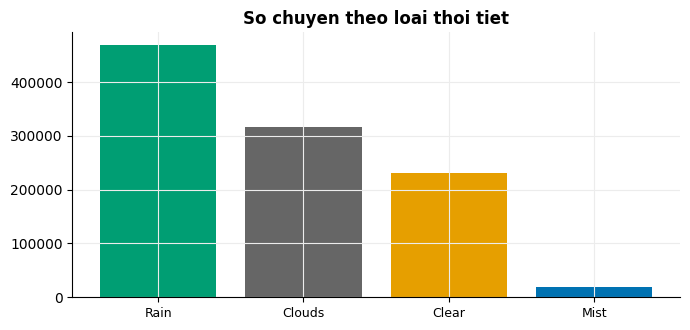

In [2]:
wc = df.weather_main.value_counts()
print("Phan bo loai thoi tiet:", wc.to_dict())
print(f"weather_missing (thieu quan sat): {df.weather_missing.mean()*100:.2f}%")
fig, ax = plt.subplots(figsize=(7,3.4))
ax.bar(range(len(wc)), wc.values, color=[GREEN,MUT,ORANGE,BLUE,PURPLE,RED][:len(wc)])
ax.set_xticks(range(len(wc))); ax.set_xticklabels(wc.index, fontsize=9)
ax.set_title("So chuyen theo loai thoi tiet", fontweight="bold"); plt.tight_layout(); plt.show()

## 2. Giá & surge theo loại thời tiết

,n,gia_median_k,surge_rate,surge_mean,toc_do_kmh
weather_main,,,,,
Clouds,316381,111.0,0.831,1.144,17.265
Rain,468851,119.0,0.828,1.194,15.574
Clear,230933,110.0,0.780,1.139,17.374
Mist,18385,112.0,0.751,1.125,17.082


eta(thoi tiet, GIA)=0.097 | eta(thoi tiet, SURGE)=0.153


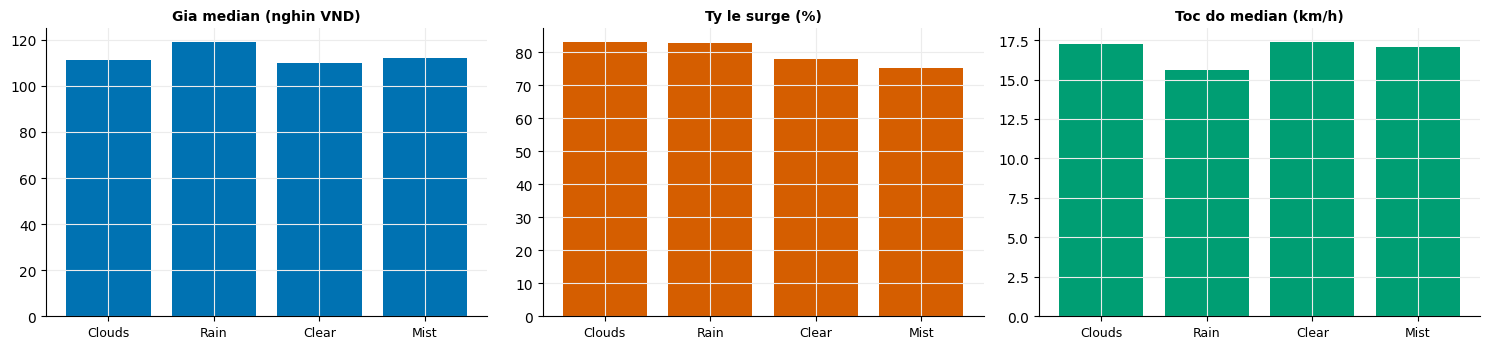

In [3]:
w = df.groupby("weather_main").agg(
    n=(PRICE,"size"), gia_median_k=("price_k","median"),
    surge_rate=("is_surge","mean"), surge_mean=(SURGE,"mean"),
    toc_do_kmh=("speed_kmh","median")).round(3).sort_values("surge_rate", ascending=False)
display(w)
print(f"eta(thoi tiet, GIA)={eta(df.weather_main, df[PRICE]):.3f} | eta(thoi tiet, SURGE)={eta(df.weather_main, df[SURGE]):.3f}")
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].bar(range(len(w)), w.gia_median_k, color=BLUE); ax[0].set_title("Gia median (nghin VND)", fontweight="bold", fontsize=10)
ax[1].bar(range(len(w)), w.surge_rate*100, color=RED); ax[1].set_title("Ty le surge (%)", fontweight="bold", fontsize=10)
ax[2].bar(range(len(w)), w.toc_do_kmh, color=GREEN); ax[2].set_title("Toc do median (km/h)", fontweight="bold", fontsize=10)
for a in ax: a.set_xticks(range(len(w))); a.set_xticklabels(w.index, fontsize=9)
plt.tight_layout(); plt.show()

## 3. Mưa vs Không mưa (so trực tiếp)

In [4]:
df["co_mua"] = (df.weather_is_rain==1) | (df.weather_is_drizzle==1) | (df.weather_is_thunderstorm==1)
cmp = df.groupby("co_mua").agg(gia_k=("price_k","median"), surge_rate=("is_surge","mean"),
                               surge_mean=(SURGE,"mean"), toc_do=("speed_kmh","median")).round(3)
cmp.index = ["Khong mua","Co mua"]
display(cmp)
# kiem soat quang duong: mua co lam gia tang khong?
r_ctrl = control_distance_corr(df, "co_mua", PRICE)
print(f"corr(co_mua, gia) trong cung dai quang duong: {r_ctrl:+.3f}")
print(f"-> Mua {'lam tang' if cmp.loc['Co mua','gia_k']>cmp.loc['Khong mua','gia_k'] else 'khong tang'} gia; "
      f"surge {'cao hon' if cmp.loc['Co mua','surge_rate']>cmp.loc['Khong mua','surge_rate'] else 'khong'} khi mua.")

,gia_k,surge_rate,surge_mean,toc_do
Khong mua,111.0,0.808,1.141,17.304
Co mua,119.0,0.828,1.194,15.574


corr(co_mua, gia) trong cung dai quang duong: +0.140
-> Mua lam tang gia; surge cao hon khi mua.


## 4. Thời tiết × Giờ (surge)

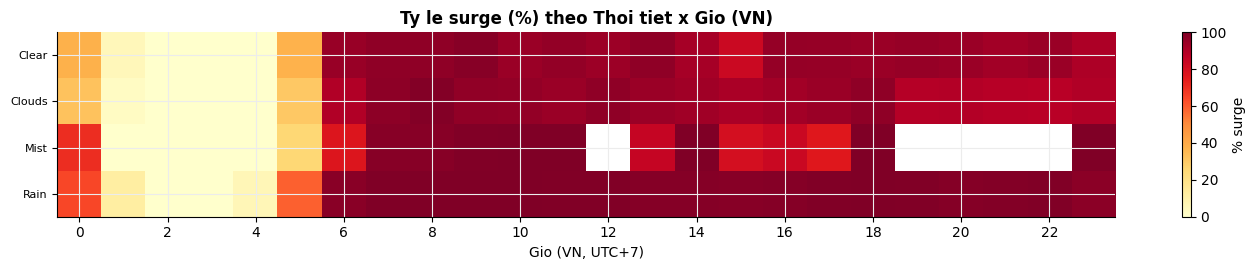

In [5]:
hm = df.pivot_table(index="weather_main", columns="gio_vn", values="is_surge", aggfunc="mean")*100
fig, ax = plt.subplots(figsize=(14, 2.8))
im = ax.imshow(hm.values, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(len(hm))); ax.set_yticklabels(hm.index, fontsize=8)
ax.set_xticks(range(0,24,2)); ax.set_xticklabels(range(0,24,2)); ax.set_xlabel("Gio (VN, UTC+7)")
ax.set_title("Ty le surge (%) theo Thoi tiet x Gio (VN)", fontweight="bold")
plt.colorbar(im, ax=ax, label="% surge"); plt.tight_layout(); plt.show()

## Kết luận — Thời tiết

- **→ Giá:** mưa có giá cao hơn nắng (do mưa → tắc + cầu tăng). Kiểm soát quãng đường vẫn thấy tác động.
- **→ Hệ số nhân:** mưa/mây làm surge cao hơn (η ~0,15). Yếu hơn giờ/vị trí nhưng **có thật**,
  khác Boston ≈0 — vì HCM có tắc đường & cung–cầu để thời tiết tác động qua đó.